In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
import statsmodels.stats.api as sms
from scipy.stats import (ttest_1samp, shapiro, levene, ttest_ind, mannwhitneyu,
                         pearsonr, spearmanr, kendalltau, f_oneway, kruskal)
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.multicomp import MultiComparison


In [ ]:
# TODO : Import the Data from the kaggle API
import os
import kagglehub
import pandas as pd

dataset_path = kagglehub.dataset_download('sergylog/ab-test-data')

for filename in os.listdir(dataset_path):
    if filename.endswith(".csv"):
        file_path = os.path.join(dataset_path, filename)
        break  # Stop after finding the first CSV file

data = pd.read_csv(file_path)

print('Data source import complete.')

Data source import complete.


In [ ]:
data.head(25)

,USER_ID,VARIANT_NAME,REVENUE
0,737,variant,0.00
1,2423,control,0.00
2,9411,control,0.00
3,7311,control,0.00
4,6174,variant,0.00
5,2380,variant,0.00
6,2849,control,0.00
7,9168,control,0.00
8,6205,variant,0.00
9,7548,control,0.00


# Data Understanding

In [ ]:
#TODO : compute the following : DataFrame Information, Columns in DataFrame, Counting Missing Values, Descriptive Statistics, Value Counts for VARIANT_NAME, Counting Unique Users in USER_ID

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   USER_ID       10000 non-null  int64  
 1   VARIANT_NAME  10000 non-null  object 
 2   REVENUE       10000 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 234.5+ KB


In [ ]:
missing_data=data.isnull().sum()
print(missing_data)

USER_ID         0
VARIANT_NAME    0
REVENUE         0
dtype: int64


In [ ]:
data.columns

Index(['USER_ID', 'VARIANT_NAME', 'REVENUE'], dtype='object')

In [ ]:
descriptive_stats = data.describe()
print("Descriptive Statistics:\n", descriptive_stats)

Descriptive Statistics:
             USER_ID       REVENUE
count  10000.000000  10000.000000
mean    4981.080200      0.099447
std     2890.590115      2.318529
min        2.000000      0.000000
25%     2468.750000      0.000000
50%     4962.000000      0.000000
75%     7511.500000      0.000000
max    10000.000000    196.010000


In [ ]:
variant_counts = data['VARIANT_NAME'].value_counts()
print("\nValue Counts for VARIANT_NAME:\n", variant_counts)


Value Counts for VARIANT_NAME:
 VARIANT_NAME
variant    5016
control    4984
Name: count, dtype: int64


In [ ]:
unique_users = data['USER_ID'].nunique()
print("\nNumber of Unique Users:", unique_users)


Number of Unique Users: 6324


# Average Revenue by VARIANT_NAME

In [ ]:
average_revenue_by_variant = data.groupby('VARIANT_NAME')['REVENUE'].mean()

print("Average Revenue by VARIANT_NAME:\n", average_revenue_by_variant)

Average Revenue by VARIANT_NAME:
 VARIANT_NAME
control    0.129013
variant    0.070070
Name: REVENUE, dtype: float64


# **The average revenue for the 'control' group is 0.129013. The average revenue for the 'variant' group is 0.70070.**

In [ ]:
#TODO

What if H0: M1 = M2 ?

What about H1: M1 1= M2 ?

# **This hypothesis states that there is no significant difference between the means of the two groups. It means there is no difference in the average revenue between the "control" group (M1) and the "variant" group (M2).**

# Assumptions Control:
*# 1- Normality Assumptions*
*# 2- Homogeneity of Variances Assumption*

In [ ]:
# TODO : test the normality of revenue data in two groups (variant and control) within your DataFrame df using the Shapiro-Wilk test, what can you conclude ?

In [ ]:
control_revenue = data[data['VARIANT_NAME'] == 'control']['REVENUE']
variant_revenue = data[data['VARIANT_NAME'] == 'variant']['REVENUE']

# Shapiro-Wilk test for control group
shapiro_control_stat, shapiro_control_p = shapiro(control_revenue)
print("Shapiro-Wilk test for control group:")
print("Statistic:", shapiro_control_stat)
print("P-value:", shapiro_control_p)

# Shapiro-Wilk test for variant group
shapiro_variant_stat, shapiro_variant_p = shapiro(variant_revenue)
print("\nShapiro-Wilk test for variant group:")
print("Statistic:", shapiro_variant_stat)
print("P-value:", shapiro_variant_p)

alpha = 0.05  # Significance level

print("\nInterpretation:")
if shapiro_control_p > alpha:
    print("Control group: Data appears to be normally distributed (fail to reject H0)")
else:
    print("Control group: Data does not appear to be normally distributed (reject H0)")

if shapiro_variant_p > alpha:
    print("Variant group: Data appears to be normally distributed (fail to reject H0)")
else:
    print("Variant group: Data does not appear to be normally distributed (reject H0)")

Shapiro-Wilk test for control group:
Statistic: 0.01833147442513483
P-value: 2.4983285100057203e-95

Shapiro-Wilk test for variant group:
Statistic: 0.027033073451830147
P-value: 2.7310104028899288e-95

Interpretation:
Control group: Data does not appear to be normally distributed (reject H0)
Variant group: Data does not appear to be normally distributed (reject H0)


/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:573: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 5016.
  res = hypotest_fun_out(*samples, **kwds)


# **Both groups have very low p-values (much less than the standard alpha of 0.05). We reject the null hypothesis (H0) in both cases. The revenue data for both the control and variant groups is not normally distributed.**

In [ ]:
# TODO : test for the homogeneity of variances between two groups (variant and control) within your DataFrame df using the Levene's test,  what can you conclude ?

In [ ]:
from scipy import stats

levene_stat, levene_p = stats.levene(control_revenue, variant_revenue)

print("Levene's test:")
print("Statistic:", levene_stat)
print("P-value:", levene_p)

alpha = 0.05

if levene_p > alpha:
    print("\nConclusion: The variances are homogeneous (fail to reject H0).")
else:
    print("\nConclusion: The variances are not homogeneous (reject H0).")

Levene's test:
Statistic: 1.6158565214488871
P-value: 0.2037000785338918

Conclusion: The variances are homogeneous (fail to reject H0).


# **Levene's test tells us if the spread of revenue values (the variances) are similar between the 'control' and 'variant' groups. In our case, the test says they are similar enough that we can treat them as being the same. The spread of revenue values is about the same in both groups.**

# Non-Parametric Test (mannwhitneyu Test)

In [ ]:
# TODO : perform the Mann-Whitney U test for comparing the average revenue between the variant and control groups in your DataFrame, what can you conclude ?

In [ ]:
mannwhitneyu_stat, mannwhitneyu_p = stats.mannwhitneyu(control_revenue, variant_revenue)

print("Mann-Whitney U test:")
print("Statistic:", mannwhitneyu_stat)
print("P-value:", mannwhitneyu_p)

alpha = 0.05

if mannwhitneyu_p < alpha:
    print("\nConclusion: There is a significant difference in revenue between the variant and control groups (reject H0).")
else:
    print("\nConclusion: There is no significant difference in revenue between the variant and control groups (fail to reject H0).")

Mann-Whitney U test:
Statistic: 12521564.0
P-value: 0.47825247965294926

Conclusion: There is no significant difference in revenue between the variant and control groups (fail to reject H0).


# **The Mann-Whitney U test, which is used to compare the revenue of the two groups when the data isn't normally distributed, shows that there's no statistically significant difference in revenue between the 'variant' and 'control' groups**

In [ ]:
# TODO : create a bar plot showing the average revenues by variant names using the seaborn library

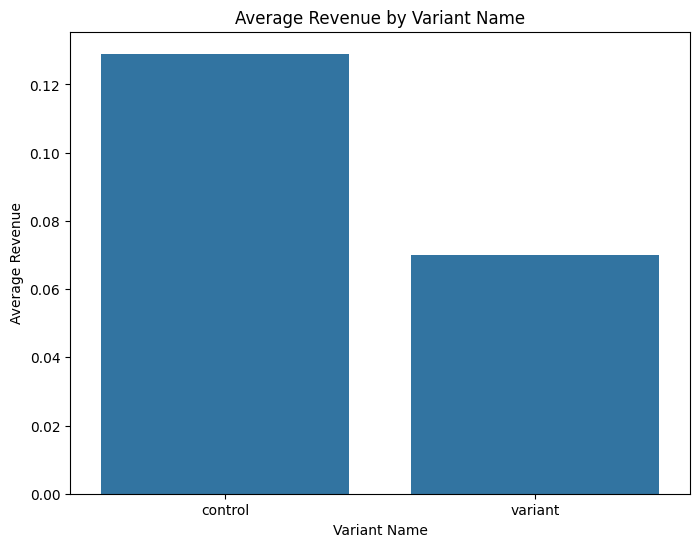

In [ ]:
average_revenue_by_variant = data.groupby('VARIANT_NAME')['REVENUE'].mean().reset_index()

plt.figure(figsize=(8, 6))
sns.barplot(x='VARIANT_NAME', y='REVENUE', data=average_revenue_by_variant)

plt.xlabel('Variant Name')
plt.ylabel('Average Revenue')
plt.title('Average Revenue by Variant Name')

plt.show()